--- Dataset Dimensions ---
Rows: 420768, Columns: 18

--- Task 3: Data Cleaning ---
Missing values per column:
 PM2.5     8739
PM10      6449
SO2       9021
NO2      12116
CO       20701
O3       13277
TEMP       398
PRES       393
DEWP       403
RAIN       390
wd        1822
WSPM       318
dtype: int64
Cleaned Dimensions: (420768, 18)
Data Cleaning Complete.

--- Task 4: Identifying the Worst Air Quality Station ---
Ranking of Stations by Average PM2.5 (Worst to Best):
1. Dongsi: 86.31
2. Wanshouxigong: 85.36
3. Nongzhanguan: 85.29
4. Gucheng: 84.35
5. Wanliu: 83.52
6. Aotizhongxin: 83.16
7. Guanyuan: 83.05
8. Tiantan: 82.26
9. Shunyi: 80.02
10. Changping: 71.12
11. Huairou: 69.95
12. Dingling: 67.43

Targeting Data for: Dongsi
Reason: Highest overall PM2.5 average (86.31)


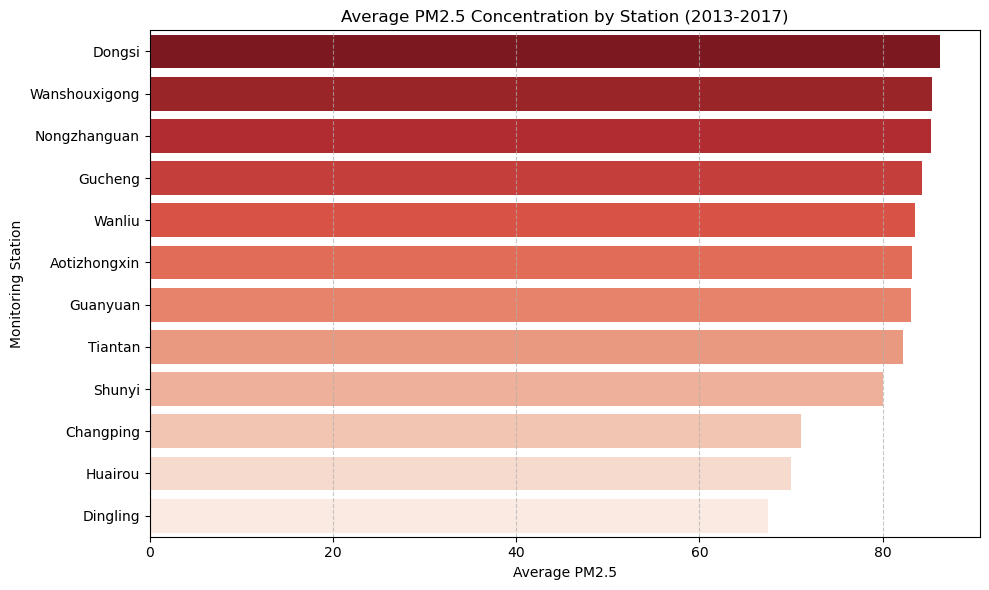


--- Task 5: Generating Visualization ---


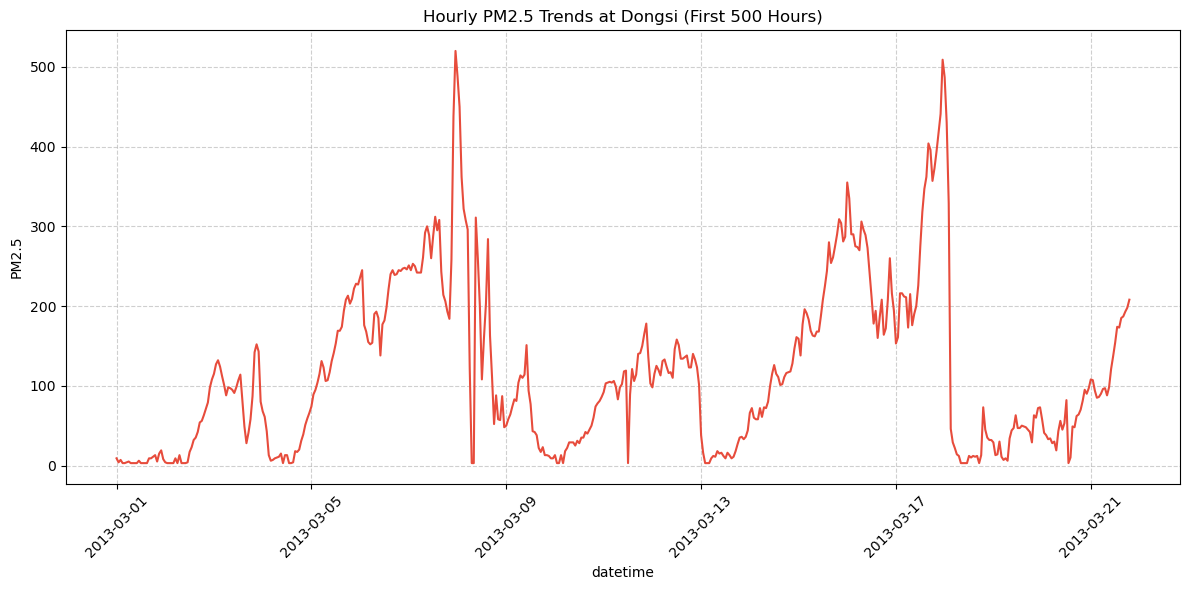


--- Task 6: Correlation Analysis ---

Correlation of PM2.5 with other variables:
PM2.5    1.000000
PM10     0.876213
CO       0.773015
NO2      0.654286
SO2      0.469207
DEWP     0.112820
PRES     0.019145
hour     0.010579
month    0.007143
day      0.004421
RAIN    -0.014153
year    -0.026516
TEMP    -0.130454
O3      -0.144707
WSPM    -0.269565
Name: PM2.5, dtype: float64


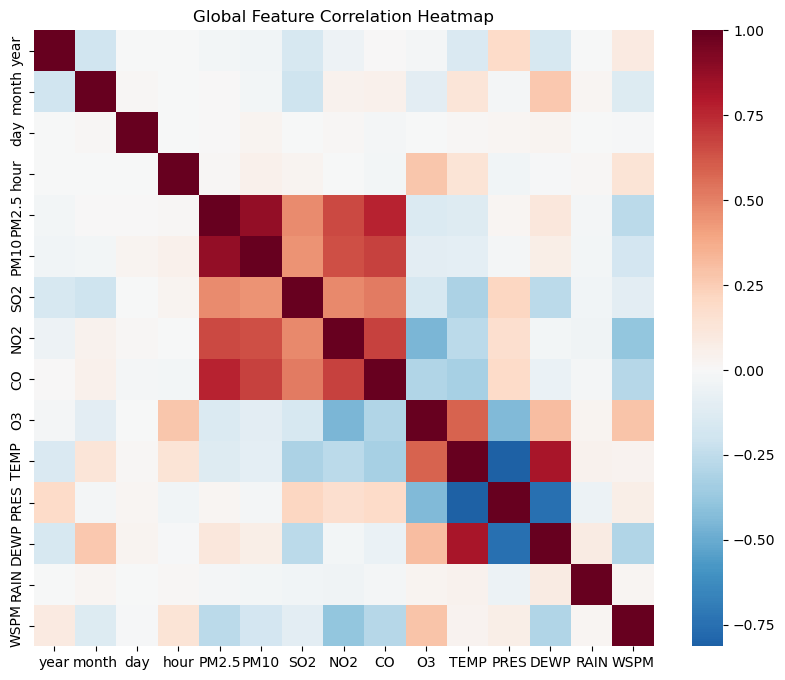

In [25]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Path to the dataset
path = r'/Users/earltavera/Desktop/MSE803/Week 2/Week2A1/beijing+multi+site+air+quality+data/PRSA_Data_20130301-20170228'

# 1. Load the dataset
all_files = glob.glob(os.path.join(path, "*.csv"))
df_list = [pd.read_csv(f) for f in all_files]
df = pd.concat(df_list, ignore_index=True)

# 2. Basic Inspection
print("--- Dataset Dimensions ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# 3. Data Cleaning
print("\n--- Task 3: Data Cleaning ---")

# Checking for missing values
missing_values = df.isnull().sum()
print("Missing values per column:\n", missing_values[missing_values > 0])

# Handling Missing Values
# I used 'forward fill' (ffill) because air quality data is a time series. 
# If a sensor fails for one hour, it's likely the air is similar to the hour before.
df = df.ffill()

# Converting Date Components to Datetime
# This makes (Visualization) much easier.
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])

# Drop unnecessary columns (optional, like 'No' which is just a row ID)
df.drop(columns=['No'], inplace=True)

print(f"Cleaned Dimensions: {df.shape}")
print("Data Cleaning Complete.")

# --- 4. Data Filtering by Station ---
print("\n--- Task 4: Identifying the Worst Air Quality Station ---")

# 1. Group the data by station and calculate the mean PM2.5
# We use sort_values(ascending=False) to put the worst station at the very top
station_pm25_means = df.groupby('station')['PM2.5'].mean().sort_values(ascending=False)

# 2. Extract the worst station (which is now the first one in our sorted list)
target_station = station_pm25_means.index[0]
worst_pm25_avg = station_pm25_means.iloc[0]

print("Ranking of Stations by Average PM2.5 (Worst to Best):")
for i, (station, avg_pm25) in enumerate(station_pm25_means.items(), 1):
    print(f"{i}. {station}: {avg_pm25:.2f}")

print(f"\nTargeting Data for: {target_station}")
print(f"Reason: Highest overall PM2.5 average ({worst_pm25_avg:.2f})")

# 3. Filter the dataset for that specific station
df_filtered = df[df['station'] == target_station]

# 4. VISUAL DISPLAY: Bar Chart Ranking
plt.figure(figsize=(10, 6))
# Using a Red color palette where the darkest red is the worst pollution
sns.barplot(x=station_pm25_means.values, y=station_pm25_means.index, hue=station_pm25_means.index, palette='Reds_r', legend=False)
plt.title("Average PM2.5 Concentration by Station (2013-2017)")
plt.xlabel("Average PM2.5")
plt.ylabel("Monitoring Station")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 5. Data Visualization
print("\n--- Task 5: Generating Visualization ---")
plt.figure(figsize=(12, 6))
# Plotting a subset (first 500 hours) using 'datetime' for a continuous timeline
sns.lineplot(data=df_filtered.iloc[:500], x='datetime', y='PM2.5', color='#e74c3c')
plt.title(f'Hourly PM2.5 Trends at {target_station} (First 500 Hours)')
plt.xticks(rotation=45) # Rotates the dates so they don't overlap
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 6. Correlation Analysis
print("\n--- Task 6: Correlation Analysis ---")
# Selecting only numeric columns and dropping NaNs for the calculation
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
corr_matrix = df[numeric_cols].corr()

# Focusing on PM2.5 correlations
print("\nCorrelation of PM2.5 with other variables:")
print(corr_matrix['PM2.5'].sort_values(ascending=False))

# Heatmap Visualization
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=False, cmap='RdBu_r', center=0)
plt.title('Global Feature Correlation Heatmap')
plt.show()